Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Load all the dataframes

In [2]:
Data_xtest = pd.read_csv('X_test.csv')
Data_xtrain = pd.read_csv('X_train.csv')
Data_ytrain = pd.read_csv('y_train.csv')
Data_output = pd.read_csv('new_output_sample.csv')

df_xtest = pd.DataFrame(data = Data_xtest)
df_xtrain = pd.DataFrame(data = Data_xtrain)
df_ytrain = pd.DataFrame(data = Data_ytrain)
df_output = pd.DataFrame(data = Data_output)

# Testing things (WIP)

In [3]:
print("xtest")
print(df_xtest.head())
print("xtrain")
print(df_xtrain.head())
print("ytrain")
print(df_ytrain.head())
print("output")
print(df_output.head())

xtest
              Horodate  123476859  123596487  123798654  123875946  123879645  \
0  2023-01-09 00:00:00      102.0      992.0      365.0      252.0       71.0   
1  2023-01-09 00:30:00       89.0      996.0      351.0      219.0       47.0   
2  2023-01-09 01:00:00      134.0      841.0      314.0      213.0       55.0   
3  2023-01-09 01:30:00      130.0      961.0      228.0      253.0       35.0   
4  2023-01-09 02:00:00      135.0      949.0      213.0      243.0       47.0   

   123897645  123947865  124367958  124568973  ...  holed_991  holed_992  \
0      132.0       30.0      201.0      121.0  ...       38.0      168.0   
1      140.0       31.0      173.0      186.0  ...       27.0       82.0   
2      114.0       38.0      204.0      251.0  ...       37.0      102.0   
3      103.0       35.0      176.0      305.0  ...       13.0       78.0   
4      472.0       21.0      187.0      283.0  ...       62.0      107.0   

   holed_993  holed_994  holed_995  holed_996  hol

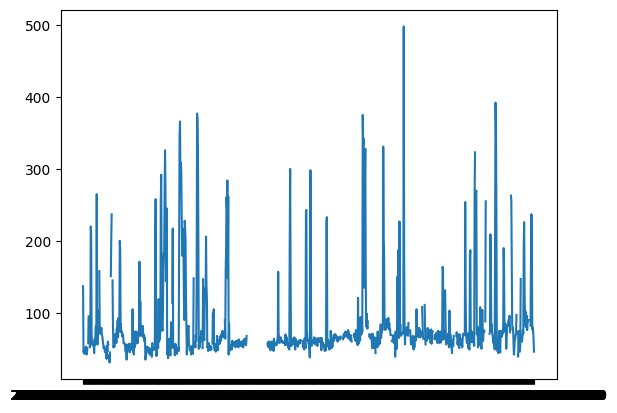

In [10]:
Xaxis = df_xtrain['Horodate']
Yaxis_holed500 = df_xtrain['holed_500']

plt.plot(Xaxis, Yaxis_holed500)
plt.show()

Dans cet affichage d'une courbe holed du dataframe xtrain, on remarque effectivement les valeurs manquantes

Importons maintenant la fonction d'interpolation de benchmark donne par les createurs du challenge

In [11]:
def fill_nan_with_interpolation(column):
    col = column.copy()
    col = col.interpolate(method='linear', limit_direction='both')
    return col

Essayons maintenant de completer cette derniere courbe holed avec l'interpolation du benchmark

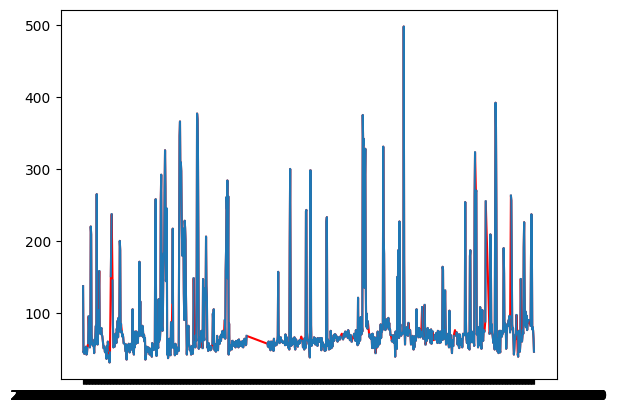

In [12]:
Yaxis_filled500 = fill_nan_with_interpolation(Yaxis_holed500)

plt.plot(Xaxis, Yaxis_filled500, 'r')
plt.plot(Xaxis, Yaxis_holed500)
plt.show()

Comme dit dans la presentation du benchmark, cette interpolation lineaire relie le dernier point connu avec le prochain point connu par une ligne droite.

En creant un fichier y_test en utilisant uniquement cette fonction d'interpolation, le score obtenu devrait etre celui du benchmark (~107).

Verifions cela:

Il nous faut completer les 1000 dernieres colonnes du dataframe x_test

In [13]:
i_start = len(df_xtest) - 1000
Y_test_filled = []

for i in range(i_start, len(df_xtest)):
    Yfilled = fill_nan_with_interpolation(df_xtest[i])
    Y_test_filled.append(Yfilled)


KeyError: 57